[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/badaouihakimou/machine-learning-notebooks/blob/main/22_2_imputers.ipynb)



# Les imputers : boucher les valeurs manquantes

Les vraies données ont des trous. Un âge non renseigné, une mesure ratée, un champ
laissé vide. Or la plupart des modèles refusent les `NaN`. Il faut donc les imputer les remplacer par une valeur plausible.

Le notebook 22.1 utilisait `SimpleImputer` sans le détailler. Ici on voit toutes
les stratégies, des plus simples aux plus intelligentes, et surtout comment
garder la trace de ce qui manquait.

## Le plan

| Section | L'imputer |
|---|---|
| 1 | SimpleImputer : les quatre stratégies |
| 2 | Le fit sur le train, l'application au test |
| 3 | KNNImputer : boucher par similarité |
| 4 | MissingIndicator : garder la trace des trous |
| 5 | Combiner imputation et indicateur |
| 6 | Application : régler l'imputer par GridSearch |

## Trois pièges annoncés

L'imputer doit être `fit` sur le train, puis appliqué au test jamais réajusté.

`train_test_split` renvoie `X_train, X_test, y_train, y_test` dans cet ordre
précis. Les intervertir casse tout.

Et l'imputation doit rester dans le pipeline, sous peine de fuite d'autant
plus grave avec `KNNImputer`, qui apprend beaucoup des données.

Prérequis : les notebooks 22.0 et 22.1.

## 1. SimpleImputer : les quatre stratégies

`SimpleImputer` remplace chaque `NaN` par une valeur calculée sur sa colonne.

In [44]:
import numpy as np
from sklearn.impute import SimpleImputer

x = np.array([
    [10, 3],
    [0, 5],
    [5, 3],
    [np.nan, 3]
])

print('données avec un trou :')
print(x)

données avec un trou :
[[10.  3.]
 [ 0.  5.]
 [ 5.  3.]
 [nan  3.]]


In [45]:
imputer = SimpleImputer(missing_values=np.nan, strategy='mean')
print(imputer.fit_transform(x))

[[10.  3.]
 [ 0.  5.]
 [ 5.  3.]
 [ 5.  3.]]


Le `NaN` de la première colonne a été remplacé par la moyenne de cette colonne (10 + 0 + 5) / 3 = 5.

### Les quatre stratégies

| Stratégie | Remplace par |
|---|---|
| `'mean'` | la moyenne de la colonne |
| `'median'` | la médiane |
| `'most_frequent'` | la valeur la plus fréquente (le mode) |
| `'constant'` | une valeur fixe, via `fill_value` |

In [46]:
for strategie in ['mean', 'median', 'most_frequent']:
    imp = SimpleImputer(strategy=strategie)
    valeur = imp.fit_transform(x)[3, 0]
    print(f'{strategie:<14} -> le trou devient {valeur}')

# constante
imp = SimpleImputer(strategy='constant', fill_value=-99)
print(f'{"constant":<14} -> le trou devient {imp.fit_transform(x)[3, 0]}')

mean           -> le trou devient 5.0
median         -> le trou devient 5.0
most_frequent  -> le trou devient 0.0
constant       -> le trou devient -99.0


Comment choisir.

`'mean'` sur des données à peu près symétriques.

`'median'` dès qu'il y a une asymétrie ou des aberrations la leçon du notebook
08, confirmée à l'exercice du notebook 22.1 où la médiane battait la moyenne sur
l'âge du Titanic.

`'most_frequent'` pour les variables catégorielles, où la moyenne n'a pas de
sens on ne fait pas la moyenne de « male » et « female ».

`'constant'` pour marquer explicitement un trou, souvent par une valeur hors
plage comme -99, qu'on saura repérer.

### missing_values : le trou n'est pas toujours NaN

Parfois les données absentes sont codées autrement un 0, un -1, un 999.
`missing_values` le précise.

In [47]:
donnees = np.array([[10], [0], [5], [-1]]) # -1 code une absence

imp = SimpleImputer(missing_values=-1, strategy='mean')
print(imp.fit_transform(donnees).ravel())

[10.  0.  5.  5.]


Ici -1 signifiait « manquant ». Sans le préciser, l'imputer l'aurait pris pour une
vraie valeur et l'aurait inclus dans la moyenne une erreur silencieuse. Il faut
donc connaître comment les absences sont codées dans ses données.

## 2. Le fit sur le train, l'application au test

C'est le point méthodologique central, déjà rencontré avec les scalers.

In [48]:
x_train = np.array([
    [10, 3],
    [0, 5],
    [5, 3],
    [np.nan, 3]
])

imputer = SimpleImputer(strategy='mean')
imputer.fit(x_train)  # apprend la moyenne du train

print('moyennes apprises :', imputer.statistics_)

moyennes apprises : [5.  3.5]


`fit` calcule et mémorise la moyenne de chaque colonne, ici 5 pour la
première. Cette valeur est figée.

On l'applique ensuite au test avec `transform` pas `fit_transform` :

In [49]:
x_test = np.array([
    [12, 5],
    [40, 2],
    [5, 5],
    [np.nan, np.nan]
])

print(imputer.transform(x_test))

[[12.   5. ]
 [40.   2. ]
 [ 5.   5. ]
 [ 5.   3.5]]


Le `NaN` du test a été bouché par 5 la moyenne du train, pas du test.
C'est voulu.

Pourquoi c'est crucial. Le test doit rester inconnu. Si on avait fait
`fit_transform` sur le test, l'imputer aurait calculé une nouvelle moyenne incluant
les données de test une fuite d'information, la faute des notebooks 21 et 22.

La règle absolue : `fit` sur le train, `transform` sur le test. Le pipeline
automatise cette discipline, comme on le verra en section 6.

## 3. KNNImputer : boucher par similarité

`SimpleImputer` remplace tous les trous d'une colonne par la même valeur.
`KNNImputer` fait mieux : il regarde les lignes les plus similaires et bouche
le trou d'après elles.

In [50]:
from sklearn.impute import KNNImputer

x = np.array([
    [1, 100],
    [2, 30],
    [3, 15],
    [np.nan, 20]
])

imputer = KNNImputer(n_neighbors=1)
print(imputer.fit_transform(x))

[[  1. 100.]
 [  2.  30.]
 [  3.  15.]
 [  3.  20.]]


Le trou de la dernière ligne a été bouché par 3. Voici pourquoi.

La ligne à compléter est `[?, 20]`. `KNNImputer` cherche, sur la colonne connue
(la seconde), la ligne la plus proche de 20. C'est `[3, 15]` 15 est le plus
proche de 20. Il copie donc son premier élément : 3.

C'est le KNN du notebook 20, appliqué à l'imputation : au lieu de classer, on
emprunte la valeur du voisin le plus proche.

In [51]:
# Avec 2 voisins : moyenne des deux plus proches
imputer2 = KNNImputer(n_neighbors=2)
print(imputer2.fit_transform(x))

[[  1.  100. ]
 [  2.   30. ]
 [  3.   15. ]
 [  2.5  20. ]]


Avec `n_neighbors=2`, le trou devient la moyenne des deux lignes les plus
proches sur la colonne connue ici (3 + 2) / 2 = 2,5.

Quand l'utiliser. `KNNImputer` est plus fin que `SimpleImputer` quand les
variables sont corrélées : un âge manquant peut être mieux estimé d'après la
classe et le tarif que par la moyenne globale.

Son coût. Il calcule les distances entre toutes les lignes lent sur de gros
jeux. Et il apprend énormément des données, donc le mettre dans le pipeline est
encore plus impératif que pour `SimpleImputer` : une fuite ici serait sévère.

## 4. MissingIndicator : garder la trace des trous

Boucher un trou fait perdre une information : le fait qu'il manquait. Or ce
fait peut être précieux sur le Titanic, un âge manquant n'était pas aléatoire.

`MissingIndicator` garde cette trace sous forme de colonnes booléennes.

In [52]:
from sklearn.impute import MissingIndicator

x = np.array([
    [1, 100],
    [2, 30],
    [3, 15],
    [np.nan, 20]
])

print(MissingIndicator().fit_transform(x))

[[False]
 [False]
 [False]
 [ True]]


La sortie indique où étaient les trous : `True` là où une valeur manquait, `False`
sinon. Ici, seule la première colonne avait un trou, à la dernière ligne.

### Pourquoi c'est utile

Le fait qu'une donnée manque est parfois une information. Un revenu non déclaré
peut signaler quelque chose. Une mesure médicale absente peut vouloir dire que le
médecin n'a pas jugé utile de la prendre.

En gardant l'indicateur, on donne au modèle la possibilité d'exploiter cette
information la leçon du notebook 17, où les âges manquants du Titanic n'étaient
pas répartis au hasard.

In [53]:
# Si une ligne a plusieurs trous
x2 = np.array([
    [1, 100],
    [2, 30],
    [3, 15],
    [np.nan, np.nan]
])

print(MissingIndicator().fit_transform(x2))

[[False False]
 [False False]
 [False False]
 [ True  True]]


Ici la dernière ligne a deux trous, donc deux colonnes d'indicateur, toutes
deux `True` pour cette ligne.

## 5. Combiner imputation et indicateur

Le mieux est souvent de faire les deux : boucher les trous et garder leur
trace. `make_union` du notebook 22.1 le permet les deux en parallèle.

In [54]:
from sklearn.pipeline import make_union

x = np.array([
    [1, 100],
    [2, 30],
    [3, 15],
    [np.nan, np.nan]
])

pipeline = make_union(
    SimpleImputer(strategy='constant', fill_value=-99),
    MissingIndicator())

resultat = pipeline.fit_transform(x)
print(resultat)
print('forme :', resultat.shape)

[[  1. 100.   0.   0.]
 [  2.  30.   0.   0.]
 [  3.  15.   0.   0.]
 [-99. -99.   1.   1.]]
forme : (4, 4)


La sortie a 4 colonnes pour 2 en entrée : les 2 colonnes imputées (trous
remplacés par -99), suivies des 2 colonnes d'indicateur (où était le trou).

Le modèle reçoit ainsi le meilleur des deux mondes : des données sans `NaN`, et
l'information de ce qui manquait.

C'est le `make_union` du notebook 22.1 dans son usage le plus classique deux
vues parallèles de la même donnée, collées côte à côte.

## 6. Application : régler l'imputer par GridSearch

Sur de vraies données, on met l'imputer dans un pipeline et on règle ses
paramètres comme le reste.

In [55]:
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.linear_model import SGDClassifier
import seaborn as sns

titanic = sns.load_dataset('titanic')

x = titanic[['pclass', 'age']]
y = titanic['survived'] # un seul crochet : une Series

x_train, x_test, y_train, y_test = train_test_split(x, y, random_state=0)

### Le piège de l'ordre des retours

`train_test_split` renvoie toujours dans cet ordre :

```python
x_train, x_test, y_train, y_test = train_test_split(x, y)
```

Les deux X d'abord, les deux y ensuite. Une erreur classique est d'écrire
`x_train, y_train, x_test, y_test` ce qui met le test de X dans `y_train`, avec
des tailles incohérentes et une erreur du type « inconsistent numbers of
samples ».

### Le piège du double crochet

`y = titanic[['survived']]` avec deux crochets crée un DataFrame `(n, 1)`.
`y = titanic['survived']` avec un crochet crée une Series `(n,)`, la forme
attendue. Le double crochet provoque des avertissements.

### Le pipeline avec KNNImputer

In [56]:
from sklearn.impute import KNNImputer

model = make_pipeline(KNNImputer(), SGDClassifier(random_state=0))

params = {
    'knnimputer__n_neighbors': [1, 2, 3, 4],
}

grid = GridSearchCV(model, param_grid=params, cv=5)
grid.fit(x_train, y_train)

print('meilleur k :', grid.best_params_)
print('meilleur score :', round(grid.best_score_, 4))
print('score sur test :', round(grid.best_estimator_.score(x_test, y_test), 4))

meilleur k : {'knnimputer__n_neighbors': 2}
meilleur score : 0.6647
score sur test : 0.6502


On règle `n_neighbors` de l'imputer via la syntaxe à double underscore du notebook
22.1 : `knnimputer__n_neighbors`.

Pourquoi le pipeline est indispensable ici. `KNNImputer` calcule des distances
entre toutes les lignes il apprend énormément des données. En validation
croisée, il doit être réajusté sur chaque pli d'entraînement seulement.

Si on avait imputé avant la validation croisée, le `KNNImputer` aurait vu les
lignes de validation pour boucher les trous du train, et inversement. La fuite
serait bien plus grave qu'avec un `SimpleImputer`, qui ne calcule qu'une moyenne.

Le pipeline garantit que l'imputation, comme tout le reste, reste honnête. C'est
la règle qui traverse tout le bloc prétraitement : toute étape qui apprend des
données va dans le pipeline.

## 7. Mémo

### Les imputers

| Imputer | Principe |
|---|---|
| `SimpleImputer(strategy='mean')` | moyenne de la colonne |
| `SimpleImputer(strategy='median')` | médiane, robuste |
| `SimpleImputer(strategy='most_frequent')` | mode, pour le catégoriel |
| `SimpleImputer(strategy='constant', fill_value=v)` | valeur fixe |
| `KNNImputer(n_neighbors=k)` | d'après les lignes similaires |
| `MissingIndicator()` | garde la trace des trous |

### La discipline

```python
imputer.fit(x_train) # apprend sur le train
imputer.transform(x_test) # applique au test

# ou dans un pipeline (automatique) :
make_pipeline(KNNImputer(), SGDClassifier())
```

### Combiner imputation et trace

```python
make_union(
    SimpleImputer(strategy='constant', fill_value=-99),
    MissingIndicator())
```

### Les pièges

| Situation | Ce qui se passe |
|---|---|
| `fit_transform` sur le test | fuite d'information |
| Ordre des retours de split inversé | tailles incohérentes |
| `y` en double crochet | DataFrame au lieu de Series |
| Absence codée en -1 non déclarée | prise pour une vraie valeur |
| Imputer hors pipeline en CV | fuite, sévère avec KNNImputer |
| Boucher sans MissingIndicator | on perd l'info « ça manquait » |

## 8. Exercices

**Exercice 1**

Sur une colonne d'âge du Titanic, compare les quatre stratégies de `SimpleImputer`
en affichant la valeur qui bouche les trous à chaque fois. Laquelle choisirais-tu,
et pourquoi ? Relie à la distribution de l'âge.

**Exercice 2**

Construis un pipeline `make_union(SimpleImputer(), MissingIndicator())` suivi d'un
`SGDClassifier`, sur `pclass` et `age` du Titanic. Compare son score en validation
croisée à celui d'un simple `SimpleImputer` seul. Garder la trace des trous
aide-t-il ?

**Exercice 3**

Ce code veut imputer par KNN avant la validation croisée :

```python
imputer = KNNImputer(n_neighbors=5)
x_impute = imputer.fit_transform(x)          # sur tout x
scores = cross_val_score(SGDClassifier(), x_impute, y, cv=5)
```

Explique pourquoi cette fuite est plus grave qu'avec un `SimpleImputer`, puis
corrige avec un pipeline.

## Pour continuer

Tu maîtrises maintenant tout le traitement des valeurs manquantes, de la moyenne
simple à l'imputation par similarité. Ces trous sont partout dans les vraies
données savoir les combler proprement, sans fuite, est une compétence
quotidienne.

Les notebooks suivants reviendront à la modélisation : sélection de variables,
modèles d'ensemble, apprentissage non supervisé. Le pipeline restera l'ossature
qui garantit que chaque étape imputation comprise reste honnête.

In [57]:
# Exercice 1

In [58]:
import seaborn as sns
from sklearn.impute import SimpleImputer

titanic = sns.load_dataset('titanic')
age = titanic[['age']]

print('Valeur qui bouche les trous selon la stratégie :\n')

for strategie in ['mean', 'median', 'most_frequent']:
    imputer = SimpleImputer(strategy=strategie)
    imputer.fit(age)
    print(f'{strategie:<14} -> {imputer.statistics_[0]:.2f}')

# constante : on choisit la valeur
imputer = SimpleImputer(strategy='constant', fill_value=0)
print(f'{"constant (0)":<14} -> 0.00')

Valeur qui bouche les trous selon la stratégie :

mean           -> 29.70
median         -> 28.00
most_frequent  -> 24.00
constant (0)   -> 0.00


asymétrie de l'âge : 0.389


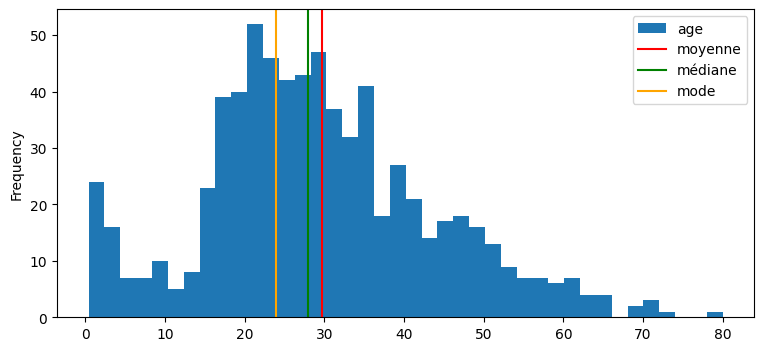

In [59]:
print('asymétrie de l\'âge :', round(titanic['age'].skew(), 3))

titanic['age'].plot(kind='hist', bins=40, figsize=(9, 4))
import matplotlib.pyplot as plt
for val, coul, lab in [(29.7, 'red', 'moyenne'), (28, 'green', 'médiane'), (24, 'orange', 'mode')]:
    plt.axvline(val, color=coul, label=lab)
plt.legend()
plt.show()

In [60]:
# Exercice 2

In [61]:
import seaborn as sns
from sklearn.impute import SimpleImputer, MissingIndicator
from sklearn.pipeline import make_pipeline, make_union
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import cross_val_score

titanic = sns.load_dataset('titanic')
x = titanic[['pclass', 'age']]
y = titanic['survived']

# Version simple : imputation seule
simple = make_pipeline(
    SimpleImputer(),
    SGDClassifier(random_state=0))

# Version avec trace des trous
avec_trace = make_pipeline(
    make_union(SimpleImputer(), MissingIndicator()),
    SGDClassifier(random_state=0))

print('SimpleImputer seul :', round(cross_val_score(simple, x, y, cv=5).mean(), 4))
print('Imputer + MissingIndicator:', round(cross_val_score(avec_trace, x, y, cv=5).mean(), 4))

SimpleImputer seul : 0.6667
Imputer + MissingIndicator: 0.6645


In [62]:
titanic['age_manquant'] = titanic['age'].isna()
print(titanic.groupby('age_manquant')['survived'].mean())

age_manquant
False    0.406162
True     0.293785
Name: survived, dtype: float64


In [63]:
# Exercice 3

In [64]:
imputer = KNNImputer(n_neighbors=5)
x_impute = imputer.fit_transform(x) # sur tout x
scores = cross_val_score(SGDClassifier(), x_impute, y, cv=5)

In [65]:
import numpy as np
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import make_pipeline
import seaborn as sns

titanic = sns.load_dataset('titanic')
x = titanic[['pclass', 'age', 'fare']]
y = titanic['survived']

# Fuite avec KNN
knn = KNNImputer(n_neighbors=5)
x_fuite = knn.fit_transform(x)
score_fuite = cross_val_score(SGDClassifier(random_state=0), x_fuite, y, cv=5).mean()

# Propre
pipe = make_pipeline(KNNImputer(n_neighbors=5), SGDClassifier(random_state=0))
score_propre = cross_val_score(pipe, x, y, cv=5).mean()

print(f'KNN avec fuite : {score_fuite:.4f}')
print(f'KNN propre : {score_propre:.4f}')

KNN avec fuite : 0.6353
KNN propre : 0.6376
